--- Class Balance (Training Set) ---
label
0    0.602991
1    0.397009
Name: proportion, dtype: float64

--- Class Balance (Test Set) ---
label
0    0.603261
1    0.396739
Name: proportion, dtype: float64


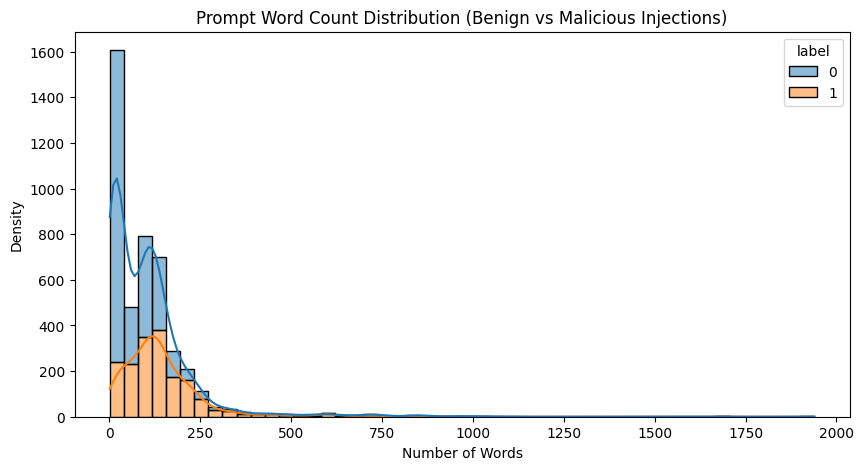

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create the results directory just in case it isn't there
os.makedirs("../results", exist_ok=True)

# 1. Load the frozen splits from the data folder
train_df = pd.read_csv("../data/frozen_train_set.csv")
test_df = pd.read_csv("../data/frozen_test_set.csv")

# 2. Print class balance ratios to prove the data isn't skewed (eg: 95% benign, 5% malicious)
print("--- Class Balance (Training Set) ---")
print(train_df['label'].value_counts(normalize=True))

print("\n--- Class Balance (Test Set) ---")
print(test_df['label'].value_counts(normalize=True))

# 3. Document Word lengths to map the attack taxonomy
train_df['word_count'] = train_df['text'].apply(lambda x: len(str(x).split()))

# 4. Plot Text Length Distributions by Class
plt.figure(figsize=(10, 5))
sns.histplot(data=train_df, x="word_count", hue="label", kde=True, multiple="stack", bins=50)
plt.title("Prompt Word Count Distribution (Benign vs Malicious Injections)")
plt.xlabel("Number of Words")
plt.ylabel("Density")

# 5. Save the graph for final technical report
plt.savefig("../results/word_count_distribution.png")
plt.show()

Exploratory Data Analysis confirms a healthy class distribution of approximately 60.3% benign instances and 39.7% adversarial injections. Stratified sampling was successfully implemented during the 80/20 train-test split, ensuring the frozen test partition maintains an identical class ratio (60.3% / 39.7%) to prevent data leakage and guarantee representative baseline evaluations